# NB01 — Identity-Disjoint Specimen Construction and Splits (run first)

Builds a grouping key, `specimen_id`, that identifies which images in BDLitchi depict
the same physical leaf, and produces the train/validation/test partitions used
throughout the rest of this project. Perceptual-hash (pHash) clustering alone catches
burst-shot near-duplicate frames but not a second photograph of the same leaf taken
from a different angle or under different lighting. `specimen_id` is defined as the
connected components of a graph in which two images are linked whenever either their
pHash Hamming distance is small, or they were captured in the same session within a
short time window. Every split downstream partitions on `specimen_id`, never on
individual images.

### Outputs (publish as a Kaggle Dataset; attached by NB02–NB06)
| file | purpose |
|---|---|
| `manifest_full.csv` | one row per image: label, session_id, cluster_id, specimen_id, split columns |
| `splits.json` | frozen split definition and counts |
| `split_diagnostics.csv` | per-class specimen/session counts, single-session flags |

### Split design
1. `common_test` — a specimen-disjoint held-out set (~15% of specimens per class),
   reserved and never trained on by any condition. This is the shared evaluation set
   used across every downstream comparison.
2. From the remaining pool:
   - **naive** condition: image-level random train/val/test (specimens can span partitions)
   - **group** condition: specimen-disjoint train/val/test
3. NB02 trains one model per condition and reports both the reporting inflation (each
   condition scored on its own test set) and the true generalisation gap (both
   conditions scored on `common_test`).

Runtime: ~20–40 minutes (CPU-bound: EXIF and pHash extraction over ~11k images). No GPU required.


In [1]:
# ===== Imports =====
import os, json, time, random, warnings, math
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import timm

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, matthews_corrcoef, confusion_matrix, roc_auc_score)

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')


device: cuda | Tesla T4


In [2]:
# ===== Config =====
RAW_DATASET_DIR = '/kaggle/input/datasets/alenmaruf/bdlithi/Dataset'   # <-- EDIT to your dataset path
OUT_DIR = Path('/kaggle/working/revision_splits'); OUT_DIR.mkdir(parents=True, exist_ok=True)

MASTER_SEED          = 42
PHASH_THRESHOLD      = 5     # Hamming distance <= this -> near-duplicate edge
SESSION_GAP_SECONDS  = 300   # > 5 min gap starts a new session

# SPECIMEN_BLOCK_SECONDS: a specimen is a contiguous run of images inside one session
# whose TOTAL SPAN is at most this many seconds.
#
# This is a bounded block, NOT a "gap to the previous photo". That distinction matters:
# BDLitchi was shot continuously (~12 s between frames), so a gap-based rule chains
# transitively (A-B-C-D...) and collapses an entire session into one group. Capping the
# span instead keeps groups bounded.
#
# Larger  -> fewer, longer blocks -> stricter identity separation, fewer independent units
# Smaller -> more blocks -> weaker separation (approaches pHash-only grouping)
# Run the sweep in cell 4b before committing to a value.
SPECIMEN_BLOCK_SECONDS = 30

COMMON_TEST_FRAC     = 0.15  # fraction of SPECIMENS per class reserved as common test
VAL_FRAC             = 0.15  # of the remaining pool
TEST_FRAC            = 0.15  # of the remaining pool

print('raw dir exists:', Path(RAW_DATASET_DIR).exists())

raw dir exists: True


In [3]:
def set_all_seeds(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(MASTER_SEED)

In [4]:
# ===== 1. Scan images + read EXIF timestamps =====
import imagehash
from PIL import ExifTags

EXIF_DT = {v:k for k,v in ExifTags.TAGS.items()}.get('DateTimeOriginal')

def exif_ts(p):
    try:
        ex = Image.open(p)._getexif()
        if ex and EXIF_DT in ex:
            return time.mktime(time.strptime(ex[EXIF_DT], '%Y:%m:%d %H:%M:%S'))
    except Exception:
        pass
    return None

rows=[]
classes = sorted([d.name for d in Path(RAW_DATASET_DIR).iterdir() if d.is_dir()])
print('classes:', len(classes), classes)
for c in classes:
    for p in sorted((Path(RAW_DATASET_DIR)/c).glob('*')):
        if p.suffix.lower() not in ('.jpg','.jpeg','.png','.bmp','.webp'): continue
        rows.append({'filepath':str(p),'filename':p.name,'label':c,
                     'ts':exif_ts(p),'mtime':p.stat().st_mtime})
df=pd.DataFrame(rows)
print('images found:', len(df), '| with EXIF timestamp:', df.ts.notna().sum())

# fall back to file mtime where EXIF is missing, so session logic still works
df['ts_eff'] = df.ts.fillna(df.mtime)
df = df.sort_values(['label','ts_eff']).reset_index(drop=True)
df.head()

classes: 11 ['Black Spot', 'Burned Leaf', 'Dried Leaf', 'Fungal Stripe Damage', 'Healthy Leaf', 'Insect Chewing Damage', 'Leaf Blight Disease', 'Pest-Affected Dry Leaf', 'Red Rust Disease', 'White Spot', 'Yellow Mosaic Virus']
images found: 11094 | with EXIF timestamp: 11094


,filepath,filename,label,ts,mtime,ts_eff
0,/kaggle/input/datasets/alenmaruf/bdlithi/Datas...,IMG20250601101600.jpg,Black Spot,1.748773e+09,1.787004e+09,1.748773e+09
1,/kaggle/input/datasets/alenmaruf/bdlithi/Datas...,IMG20250601101612.jpg,Black Spot,1.748773e+09,1.787004e+09,1.748773e+09
2,/kaggle/input/datasets/alenmaruf/bdlithi/Datas...,IMG20250601101626.jpg,Black Spot,1.748773e+09,1.787004e+09,1.748773e+09
3,/kaggle/input/datasets/alenmaruf/bdlithi/Datas...,IMG20250601101635.jpg,Black Spot,1.748773e+09,1.787004e+09,1.748773e+09
4,/kaggle/input/datasets/alenmaruf/bdlithi/Datas...,IMG20250601101759.jpg,Black Spot,1.748773e+09,1.787004e+09,1.748773e+09


In [5]:
# ===== 2. Sessions (time-gap based, within class) =====
sess=[]; sid=0; prev_lab=None; prev_t=None
for r in df.itertuples():
    if prev_lab!=r.label or prev_t is None or (r.ts_eff-prev_t)>SESSION_GAP_SECONDS:
        sid+=1
    sess.append(f'sess{sid:04d}'); prev_lab, prev_t = r.label, r.ts_eff
df['session_id']=sess
print('sessions:', df.session_id.nunique())
print(df.groupby('label').session_id.nunique().rename('n_sessions'))

sessions: 26
label
Black Spot                4
Burned Leaf               3
Dried Leaf                2
Fungal Stripe Damage      1
Healthy Leaf              3
Insect Chewing Damage     4
Leaf Blight Disease       1
Pest-Affected Dry Leaf    2
Red Rust Disease          4
White Spot                1
Yellow Mosaic Virus       1
Name: n_sessions, dtype: int64


In [6]:
# ===== 3. pHash =====
t0=time.time()
df['phash']=[imagehash.phash(Image.open(p)) for p in df.filepath]
print(f'pHash done in {time.time()-t0:.0f}s')

pHash done in 54s


In [7]:
# ===== 4. specimen_id = pHash near-duplicates UNION bounded temporal blocks =====
class UF:
    def __init__(s,n): s.p=list(range(n))
    def find(s,x):
        while s.p[x]!=x: s.p[x]=s.p[s.p[x]]; x=s.p[x]
        return x
    def union(s,a,b):
        ra,rb=s.find(a),s.find(b)
        if ra!=rb: s.p[rb]=ra

def popcount64(x):
    x = x - ((x >> np.uint64(1)) & np.uint64(0x5555555555555555))
    x = (x & np.uint64(0x3333333333333333)) + ((x >> np.uint64(2)) & np.uint64(0x3333333333333333))
    x = (x + (x >> np.uint64(4))) & np.uint64(0x0f0f0f0f0f0f0f0f)
    return (x * np.uint64(0x0101010101010101)) >> np.uint64(56)

hbits = np.array([int(str(h),16) for h in df.phash], dtype=np.uint64)
TS    = df.ts_eff.values

# --- pHash edges (independent of the block size, so computed once) ---
t0=time.time(); phash_edges=[]
for lab, g in df.groupby('label'):
    idx=g.index.to_numpy(); H=hbits[idx]
    D=popcount64(H[:,None]^H[None,:])
    iu,ju=np.triu_indices(len(idx),k=1)
    near=D[iu,ju]<=PHASH_THRESHOLD
    phash_edges.extend(zip(idx[iu[near]], idx[ju[near]]))
print(f'pHash edges: {len(phash_edges)}  ({time.time()-t0:.0f}s)')

def temporal_blocks(span_s):
    """BOUNDED blocks: start a new block when the current block's span exceeds span_s.
    Non-transitive by construction, so continuous shooting cannot chain a whole session."""
    blk=np.empty(len(df),dtype=np.int64); b=0
    for _,g in df.groupby('session_id', sort=False):
        gi=g.index.to_numpy(); gt=g.ts_eff.values
        o=np.argsort(gt,kind='stable'); gi,gt=gi[o],gt[o]
        b+=1; start=gt[0]
        for k in range(len(gi)):
            if gt[k]-start > span_s:
                b+=1; start=gt[k]
            blk[gi[k]]=b
    return blk

def build_specimens(span_s):
    uf=UF(len(df))
    for i_,j_ in phash_edges: uf.union(int(i_),int(j_))
    if span_s>0:
        blk=temporal_blocks(span_s)
        o=np.argsort(blk,kind='stable'); bs=blk[o]
        starts=np.flatnonzero(np.r_[True, bs[1:]!=bs[:-1]])
        for s_,e_ in zip(starts, np.r_[starts[1:], len(o)]):
            grp=o[s_:e_]
            for x in grp[1:]: uf.union(int(grp[0]), int(x))
    return np.array([uf.find(i_) for i_ in range(len(df))])

# cluster_id = pHash only (what the OLD paper used)
uf_c=UF(len(df))
for i_,j_ in phash_edges: uf_c.union(int(i_),int(j_))
df['cluster_id']=[f'c{uf_c.find(i_):05d}' for i_ in range(len(df))]
print('pHash-only clusters:', df.cluster_id.nunique())

pHash edges: 25044  (0s)
pHash-only clusters: 5923


In [8]:
# ===== 4b. SENSITIVITY SWEEP - pick SPECIMEN_BLOCK_SECONDS from data =====
# No images are ever discarded at any setting; only the grouping changes.
sweep=[]
for span in [0, 15, 30, 60, 120, 300, 600]:
    sid=build_specimens(span)
    per=df.assign(_s=sid).groupby('label')._s.nunique()
    sweep.append({'block_span_s':span,
                  'specimens':int(len(np.unique(sid))),
                  'mean_imgs_per_specimen':round(len(df)/len(np.unique(sid)),2),
                  'min_specimens_in_a_class':int(per.min()),
                  'worst_class':per.idxmin(),
                  'classes_under_20_spec':int((per<20).sum())})
sw=pd.DataFrame(sweep); sw.to_csv(OUT_DIR/'specimen_block_sensitivity.csv',index=False)
print(sw.to_string(index=False))
print(f"""
HOW TO READ THIS
  block_span_s = 0        pHash-only grouping (what the OLD paper did - too weak,
                          it does not keep the same leaf shot from another angle together)
  min_specimens_in_a_class
                          must stay well above ~20 so every class can still fill
                          train / val / test after splitting
  classes_under_20_spec   must be 0 at the value you choose

RECOMMENDATION
  Pick the LARGEST block_span_s where classes_under_20_spec is still 0.
  Larger = stricter identity separation = the safer direction for a leakage audit.
  Current setting: SPECIMEN_BLOCK_SECONDS = {SPECIMEN_BLOCK_SECONDS} s
  Put this table in the supplement: it shows the split was not tuned to flatter the result.""")

 block_span_s  specimens  mean_imgs_per_specimen  min_specimens_in_a_class          worst_class  classes_under_20_spec
            0       5923                    1.87                       133         Healthy Leaf                      0
           15       1609                    6.89                        38  Leaf Blight Disease                      0
           30        854                   12.99                        21  Leaf Blight Disease                      0
           60        418                   26.54                        11         Healthy Leaf                      2
          120        177                   62.68                         2  Leaf Blight Disease                      8
          300         53                  209.32                         1         Healthy Leaf                     11
          600         30                  369.80                         1 Fungal Stripe Damage                     11

HOW TO READ THIS
  block_span_s = 0        pHas

In [9]:
# ===== 4c. Apply the chosen setting =====
sid=build_specimens(SPECIMEN_BLOCK_SECONDS)
df['specimen_id']=[f's{v:06d}' for v in sid]
print(f'SPECIMEN_BLOCK_SECONDS = {SPECIMEN_BLOCK_SECONDS}')
print('pHash clusters    :', df.cluster_id.nunique())
print('specimens         :', df.specimen_id.nunique())
print('mean imgs/specimen: %.2f' % (len(df)/df.specimen_id.nunique()))
ps=df.groupby('label').specimen_id.nunique()
print('\nspecimens per class:'); print(ps.to_string())
if ps.min()<20:
    print(f'\n*** STOP: "{ps.idxmin()}" has only {ps.min()} specimens. Lower '
          f'SPECIMEN_BLOCK_SECONDS and re-run from cell 4c. Do NOT proceed to NB02. ***')
else:
    print(f'\nOK - smallest class has {ps.min()} specimens; splitting is viable.')

SPECIMEN_BLOCK_SECONDS = 30
pHash clusters    : 5923
specimens         : 854
mean imgs/specimen: 12.99

specimens per class:
label
Black Spot                143
Burned Leaf                82
Dried Leaf                 87
Fungal Stripe Damage       51
Healthy Leaf               24
Insect Chewing Damage      57
Leaf Blight Disease        21
Pest-Affected Dry Leaf    127
Red Rust Disease           40
White Spot                 62
Yellow Mosaic Virus       160

OK - smallest class has 21 specimens; splitting is viable.


In [10]:
# ===== 5. Diagnostics for the manuscript (concern #2) =====
diag = df.groupby('label').agg(
    n_images=('filename','size'),
    n_sessions=('session_id','nunique'),
    n_clusters=('cluster_id','nunique'),
    n_specimens=('specimen_id','nunique')).reset_index()
diag['single_session'] = diag.n_sessions==1
diag['imgs_per_specimen'] = (diag.n_images/diag.n_specimens).round(2)
diag.to_csv(OUT_DIR/'split_diagnostics.csv', index=False)
print(diag.to_string(index=False))
print()
ss = diag[diag.single_session].label.tolist()
print('SINGLE-SESSION CLASSES (session-disjoint splitting is impossible for these):')
print(' ', ss if ss else 'none')
print('\nState this explicitly in the manuscript Limitations (concern #2).')

                 label  n_images  n_sessions  n_clusters  n_specimens  single_session  imgs_per_specimen
            Black Spot      1045           4         979          143           False               7.31
           Burned Leaf      1171           3         437           82           False              14.28
            Dried Leaf       934           2         875           87           False              10.74
  Fungal Stripe Damage       922           1         141           51            True              18.08
          Healthy Leaf       988           3         133           24           False              41.17
 Insect Chewing Damage      1160           4         219           57           False              20.35
   Leaf Blight Disease       965           1         177           21            True              45.95
Pest-Affected Dry Leaf       879           2         862          127           False               6.92
      Red Rust Disease      1079           4         29

In [ ]:
# ===== 5b. Image quality metrics for the manuscript (Table 2 / Fig. 4) =====
# Per-image blur (Laplacian variance) and entropy (Shannon entropy of the grayscale
# intensity histogram), aggregated per class. Descriptive only: these proxies do not
# feed the specimen construction or splitting logic above -- they characterise
# capture-condition heterogeneity (focus, exposure, texture complexity) across
# classes and sessions, and are used later as an input to the difficulty-
# stratification analysis (NB07).
from scipy.ndimage import convolve

def laplacian_var(path_):
    try:
        img = np.array(Image.open(path_).convert('L'))
        lap = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)
        return float(convolve(img.astype(np.float32), lap).var())
    except Exception:
        return np.nan

def image_entropy(path_):
    try:
        img = np.array(Image.open(path_).convert('L')).flatten()
        hist, _ = np.histogram(img, bins=256, range=(0, 256))
        hist = hist / hist.sum()
        hist = hist[hist > 0]
        return float(-np.sum(hist * np.log2(hist)))
    except Exception:
        return np.nan

print('Computing per-image blur and entropy (a few minutes over 11,094 images)...')
df['blur_score']    = df['filepath'].apply(laplacian_var)
df['entropy_score'] = df['filepath'].apply(image_entropy)

quality = df.groupby('label').agg(
    n_images=('filename', 'size'),
    n_sessions=('session_id', 'nunique'),
    mean_blur=('blur_score', 'mean'),
    std_blur=('blur_score', 'std'),
    mean_entropy=('entropy_score', 'mean'),
    images_per_session_mean=('session_id', lambda x: len(x) / x.nunique()),
).reset_index().rename(columns={'label': 'Class'})
quality.to_csv(OUT_DIR / 'dataset_statistics_per_class.csv', index=False)
print(quality.round(2).to_string(index=False))

# --- LaTeX table matching manuscript Table 2 (tab:dataset_stats) ---
tex_tbl = quality.rename(columns={'n_images': 'Images', 'n_sessions': 'Sessions',
    'mean_blur': 'Mean blur', 'std_blur': 'Std blur', 'mean_entropy': 'Mean entropy',
    'images_per_session_mean': 'Img/session'})
tex_tbl = tex_tbl[['Class', 'Images', 'Sessions', 'Mean blur', 'Std blur', 'Mean entropy', 'Img/session']]
latex_quality = tex_tbl.to_latex(index=False, escape=True, column_format='lrrrrrr',
    float_format=lambda v: f'{v:.2f}',
    caption='Per-class dataset composition and image-quality statistics (raw, pre-deduplication pool). '
            'Blur is Laplacian variance (higher = sharper); entropy is Shannon entropy of the grayscale '
            'intensity histogram (bits).',
    label='tab:dataset_stats')
open(OUT_DIR / 'table_dataset_stats.tex', 'w').write(latex_quality)
print(latex_quality)

# --- Fig 4: blur & entropy boxplots per class ---
FIGD_Q = OUT_DIR / 'figures'; FIGD_Q.mkdir(exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df.boxplot(column='blur_score', by='label', ax=axes[0], rot=45)
axes[0].set_title('Blur score (Laplacian variance) per class')
axes[0].set_ylabel('Laplacian variance'); axes[0].set_xlabel('')
df.boxplot(column='entropy_score', by='label', ax=axes[1], rot=45)
axes[1].set_title('Image entropy per class')
axes[1].set_ylabel('Entropy (bits)'); axes[1].set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.savefig(FIGD_Q / 'fig04_image_quality_per_class.png', bbox_inches='tight')
plt.show()
print('Saved dataset_statistics_per_class.csv, table_dataset_stats.tex, fig04_image_quality_per_class.png')


In [11]:
# ===== 6. Build the splits =====
rng=np.random.RandomState(MASTER_SEED)

def _stable_seed(base, key):
    import zlib
    return (base + zlib.crc32(str(key).encode())) % (2**31-1)

def specimen_split(frame, fracs, seed, min_per_part=1, verbose=True):
    """Assign WHOLE specimens to parts, per class, balancing by IMAGE COUNT.

    Specimens differ enormously in size (tens to hundreds of images), so allocating
    a fixed FRACTION OF SPECIMENS produces wildly unbalanced image counts - one large
    specimen can make a class's test set larger than its train set. Instead we sort
    specimens largest-first and repeatedly give the next one to whichever part is
    furthest BELOW its image-count target (a standard greedy multiway partition).
    Specimens stay atomic; the resulting image proportions land close to the target.
    """
    names=list(fracs); nparts=len(names)
    out=pd.Series('__none__', index=frame.index)
    starved=[]; report=[]
    for lab,g in frame.groupby('label'):
        sizes=g.groupby('specimen_id').size()
        specs=list(sizes.index)
        r=np.random.RandomState(_stable_seed(seed,lab)); r.shuffle(specs)   # deterministic tie-break
        specs=sorted(specs, key=lambda s: (-int(sizes[s]), str(s)))         # largest first
        n=len(specs)
        if n < nparts*min_per_part:
            big=max(fracs,key=fracs.get)
            out[g.index]=big; starved.append((lab,n)); continue
        total=int(sizes.sum())
        target={k: fracs[k]*total for k in names}
        cur={k:0 for k in names}; assign={}
        for s in specs:                       # greedy: biggest deficit wins
            k=max(names, key=lambda k:(target[k]-cur[k], k))
            assign[s]=k; cur[k]+=int(sizes[s])
        # guarantee every part holds at least min_per_part specimens
        for _ in range(nparts*3):
            counts={k:sum(1 for v in assign.values() if v==k) for k in names}
            short=[k for k in names if counts[k]<min_per_part]
            if not short: break
            k_short=short[0]
            donors=[s for s,v in assign.items() if counts[v]>min_per_part]
            if not donors: break
            s_move=min(donors, key=lambda s:int(sizes[s]))   # move the smallest
            cur[assign[s_move]]-=int(sizes[s_move]); assign[s_move]=k_short
            cur[k_short]+=int(sizes[s_move])
        out[g.index]=g.specimen_id.map(assign)
        report.append({'label':lab, **{f'{k}_imgs':cur[k] for k in names},
                       **{f'{k}_pct':round(100*cur[k]/total,1) for k in names}})
    if starved and verbose:
        print(f'  WARNING: {len(starved)} class(es) have fewer than {nparts*min_per_part} '
              f'specimens and went entirely into one part:')
        for lab,n in starved: print(f'    - {lab}: only {n} specimen(s)')
        print('  -> identity-disjoint evaluation is impossible for these (concern #2).')
    if verbose and report:
        rep=pd.DataFrame(report).set_index('label')
        print('  image-count balance per class (%):')
        print(rep[[c for c in rep.columns if c.endswith("_pct")]].to_string())
    assert (out!='__none__').all(), 'some rows were never assigned'
    return out

# --- 6a. reserve the common, specimen-disjoint test set ---
print('Reserving common test set...')
df['reserve'] = specimen_split(df, {'common_test':COMMON_TEST_FRAC,'pool':1-COMMON_TEST_FRAC},
                               MASTER_SEED, verbose=False)
common_test = df[df.reserve=='common_test'].copy()
pool        = df[df.reserve=='pool'].copy()
print(f'common_test: {len(common_test)} imgs / {common_test.specimen_id.nunique()} specimens')
print(f'pool       : {len(pool)} imgs / {pool.specimen_id.nunique()} specimens')

# --- 6b. GROUP condition: specimen-disjoint split of the pool ---
print('\nBuilding specimen-disjoint (group) split...')
g_assign = specimen_split(pool, {'train':1-VAL_FRAC-TEST_FRAC,'val':VAL_FRAC,'test':TEST_FRAC},
                          MASTER_SEED+1)
df.loc[pool.index,'group_split'] = g_assign

# --- 6c. NAIVE condition: image-level random split of the SAME pool ---
idx=pool.index.to_numpy().copy(); rng.shuffle(idx)
n=len(idx); nv=int(VAL_FRAC*n); nt=int(TEST_FRAC*n)
naive=pd.Series(index=pool.index, dtype=object)
naive[idx[:nv]]='val'; naive[idx[nv:nv+nt]]='test'; naive[idx[nv+nt:]]='train'
df.loc[pool.index,'naive_split']=naive

df['group_split']=df['group_split'].fillna('common_test')
df['naive_split']=df['naive_split'].fillna('common_test')
print('\ngroup:'); print(df.groupby('group_split').size().to_string())
print('\nnaive:'); print(df.groupby('naive_split').size().to_string())

Reserving common test set...
common_test: 1665 imgs / 265 specimens
pool       : 9429 imgs / 589 specimens

Building specimen-disjoint (group) split...
  image-count balance per class (%):
                        train_pct  val_pct  test_pct
label                                               
Black Spot                   70.0     15.0      15.0
Burned Leaf                  70.0     15.1      15.0
Dried Leaf                   70.0     15.0      15.0
Fungal Stripe Damage         70.0     14.9      15.1
Healthy Leaf                 73.1     13.2      13.7
Insect Chewing Damage        69.9     15.0      15.1
Leaf Blight Disease          70.0     14.7      15.2
Pest-Affected Dry Leaf       70.0     15.0      15.0
Red Rust Disease             70.0     15.0      15.1
White Spot                   69.9     15.0      15.0
Yellow Mosaic Virus          70.0     15.0      15.0

group:
group_split
common_test    1665
test           1407
train          6625
val            1397

naive:
naive_split
co

In [12]:
# ===== 7. VERIFY - hard gate before NB02 =====
ok=True
def check(cond,msg):
    global ok
    print(('PASS  ' if cond else 'FAIL  ')+msg); ok = ok and bool(cond)

ct_spec=set(common_test.specimen_id); pool_spec=set(pool.specimen_id)
check(len(ct_spec & pool_spec)==0, 'common_test shares NO specimen with the training pool')

sp=df[df.group_split!='common_test'].groupby('specimen_id').group_split.nunique()
check((sp==1).all(), 'group condition: every specimen lies in exactly one of train/val/test')

spn=df[df.naive_split!='common_test'].groupby('specimen_id').naive_split.nunique()
leaked=int((spn>1).sum())
print(f'INFO  naive condition leaks {leaked}/{len(spn)} specimens across parts '
      f'({100*leaked/max(len(spn),1):.1f}%) - intentional, this is what is being measured')

# --- the check that actually matters: every class must appear in EVERY part ---
cov=df[df.group_split!='common_test'].groupby(['label','group_split']).size().unstack(fill_value=0)
for part in ['train','val','test']:
    if part not in cov.columns: cov[part]=0
missing={p:[l for l in cov.index if cov.loc[l,p]==0] for p in ['train','val','test']}
for p,ls in missing.items():
    check(len(ls)==0, f'group split: every class present in "{p}"' +
          (f'  <-- MISSING: {ls}' if ls else ''))

ctc=common_test.groupby('label').size()
miss_ct=[l for l in df.label.unique() if l not in ctc.index]
check(len(miss_ct)==0, 'every class present in common_test' +
      (f'  <-- MISSING: {miss_ct}' if miss_ct else ''))

print('\nper-class coverage (group split):'); print(cov[['train','val','test']].to_string())

if ok:
    print('\n' + '='*62)
    print('ALL CHECKS PASSED - safe to save and continue to NB02')
    print('='*62)
else:
    print('\n' + '='*62)
    print('*** CHECKS FAILED - DO NOT RUN NB02 ***')
    print('Most likely cause: SPECIMEN_BLOCK_SECONDS is too large, so classes have too')
    print('few specimens to fill every split. Lower it (see the sweep in 4b) and re-run')
    print('from cell 4c.')
    print('='*62)

PASS  common_test shares NO specimen with the training pool
PASS  group condition: every specimen lies in exactly one of train/val/test
INFO  naive condition leaks 520/589 specimens across parts (88.3%) - intentional, this is what is being measured
PASS  group split: every class present in "train"
PASS  group split: every class present in "val"
PASS  group split: every class present in "test"
PASS  every class present in common_test

per-class coverage (group split):
group_split             train  val  test
label                                   
Black Spot                622  133   133
Burned Leaf               697  150   149
Dried Leaf                556  119   119
Fungal Stripe Damage      548  117   118
Healthy Leaf              613  111   115
Insect Chewing Damage     690  148   149
Leaf Blight Disease       575  121   125
Pest-Affected Dry Leaf    523  112   112
Red Rust Disease          641  137   138
White Spot                521  112   112
Yellow Mosaic Virus       639  137  

In [13]:
# ===== 7b. Effective sample size: SPECIMENS per class per split =====
# For generalisation claims the effective n of a class is its number of independent
# SPECIMENS, not its image count. A class with 900 test images spread over 3 specimens
# supports a far weaker claim than one with 900 images over 60 specimens. This table is
# carried through to every results table so no per-class score is ever read without it.
spec_ct = (df.groupby(['label','group_split']).specimen_id.nunique()
             .unstack(fill_value=0))
for c in ['train','val','test','common_test']:
    if c not in spec_ct.columns: spec_ct[c]=0
spec_ct = spec_ct[['train','val','test','common_test']]
img_ct  = df.groupby(['label','group_split']).size().unstack(fill_value=0)
for c in ['train','val','test','common_test']:
    if c not in img_ct.columns: img_ct[c]=0
img_ct = img_ct[['train','val','test','common_test']]

eff = pd.DataFrame({
    'images_common_test'   : img_ct['common_test'],
    'specimens_common_test': spec_ct['common_test'],
    'images_test'          : img_ct['test'],
    'specimens_test'       : spec_ct['test'],
    'specimens_total'      : df.groupby('label').specimen_id.nunique(),
})
eff['imgs_per_specimen_common'] = (eff.images_common_test /
                                   eff.specimens_common_test.replace(0,np.nan)).round(1)
eff['evidence'] = np.where(eff.specimens_common_test>=10,'adequate',
                    np.where(eff.specimens_common_test>=5,'limited','very weak'))
eff = eff.sort_values('specimens_common_test')
eff.to_csv(OUT_DIR/'effective_sample_size.csv')
print('SPECIMEN-LEVEL EFFECTIVE SAMPLE SIZE (common test set)')
print(eff.to_string())
weak = eff[eff.specimens_common_test<5].index.tolist()
if weak:
    print(f'\nClasses whose common-test performance rests on <5 independent specimens:')
    for w in weak: print(f'  - {w}  ({int(eff.loc[w,"specimens_common_test"])} specimens)')
    print('  Report per-class scores for these WITH the specimen count, and say plainly')
    print('  that they cannot support a confident generalisation claim (concern #2/#5).')

# LaTeX for the supplement
tex = eff.reset_index().rename(columns={'label':'Class',
      'images_common_test':'Imgs','specimens_common_test':'Specimens',
      'imgs_per_specimen_common':'Img/spec.','evidence':'Evidence'})
open(OUT_DIR/'table_effective_sample_size.tex','w').write(
  tex[['Class','Imgs','Specimens','Img/spec.','Evidence']].to_latex(index=False,escape=True,
  column_format='lrrrl', float_format=lambda v:f'{v:.1f}',
  caption='Effective sample size of the common test set. Independent specimens, not '
          'image counts, determine how much evidence a per-class score carries.',
  label='tab:effective_n'))
print('\nSaved effective_sample_size.csv + table_effective_sample_size.tex')

SPECIMEN-LEVEL EFFECTIVE SAMPLE SIZE (common test set)
                        images_common_test  specimens_common_test  images_test  specimens_test  specimens_total  imgs_per_specimen_common  evidence
label                                                                                                                                              
Leaf Blight Disease                    144                      8          125               4               21                      18.0   limited
Healthy Leaf                           149                     11          115               8               24                      13.5  adequate
Fungal Stripe Damage                   139                     16          118               8               51                       8.7  adequate
Insect Chewing Damage                  173                     17          149              10               57                      10.2  adequate
Red Rust Disease                       163               

In [14]:
# ===== 8. Save =====
keep=['filepath','filename','label','ts_eff','session_id','cluster_id','specimen_id',
      'reserve','group_split','naive_split']
df[keep].to_csv(OUT_DIR/'manifest_full.csv', index=False)

splits={
 'seed':MASTER_SEED,
 'params':{'phash_threshold':PHASH_THRESHOLD,'session_gap_s':SESSION_GAP_SECONDS,
           'specimen_block_s':SPECIMEN_BLOCK_SECONDS,'common_test_frac':COMMON_TEST_FRAC,
           'val_frac':VAL_FRAC,'test_frac':TEST_FRAC},
 'totals':{'images':int(len(df)),'classes':int(df.label.nunique()),
           'sessions':int(df.session_id.nunique()),
           'phash_clusters':int(df.cluster_id.nunique()),
           'specimens':int(df.specimen_id.nunique())},
 'common_test':{'images':int(len(common_test)),'specimens':int(common_test.specimen_id.nunique())},
 'group_split':{k:int(v) for k,v in df.group_split.value_counts().items()},
 'naive_split':{k:int(v) for k,v in df.naive_split.value_counts().items()},
 'naive_specimens_leaked':int(leaked),
 'single_session_classes':diag[diag.single_session].label.tolist(),
 'specimens_per_class_common_test':{k:int(v) for k,v in
     df[df.group_split=='common_test'].groupby('label').specimen_id.nunique().items()},
 'specimens_per_class_total':{k:int(v) for k,v in
     df.groupby('label').specimen_id.nunique().items()},
}
json.dump(splits, open(OUT_DIR/'splits.json','w'), indent=2)
print(json.dumps(splits,indent=2))
print('\nSaved to', OUT_DIR)
print('\nNEXT: Save /kaggle/working/revision_splits as a Kaggle Dataset named '
      '"bdlitchi-revision-splits" and attach it to NB02-NB06.')

{
  "seed": 42,
  "params": {
    "phash_threshold": 5,
    "session_gap_s": 300,
    "specimen_block_s": 30,
    "common_test_frac": 0.15,
    "val_frac": 0.15,
    "test_frac": 0.15
  },
  "totals": {
    "images": 11094,
    "classes": 11,
    "sessions": 26,
    "phash_clusters": 5923,
    "specimens": 854
  },
  "common_test": {
    "images": 1665,
    "specimens": 265
  },
  "group_split": {
    "train": 6625,
    "common_test": 1665,
    "test": 1407,
    "val": 1397
  },
  "naive_split": {
    "train": 6601,
    "common_test": 1665,
    "test": 1414,
    "val": 1414
  },
  "naive_specimens_leaked": 520,
  "single_session_classes": [
    "Fungal Stripe Damage",
    "Leaf Blight Disease",
    "White Spot",
    "Yellow Mosaic Virus"
  ],
  "specimens_per_class_common_test": {
    "Black Spot": 44,
    "Burned Leaf": 27,
    "Dried Leaf": 26,
    "Fungal Stripe Damage": 16,
    "Healthy Leaf": 11,
    "Insect Chewing Damage": 17,
    "Leaf Blight Disease": 8,
    "Pest-Affected Dry

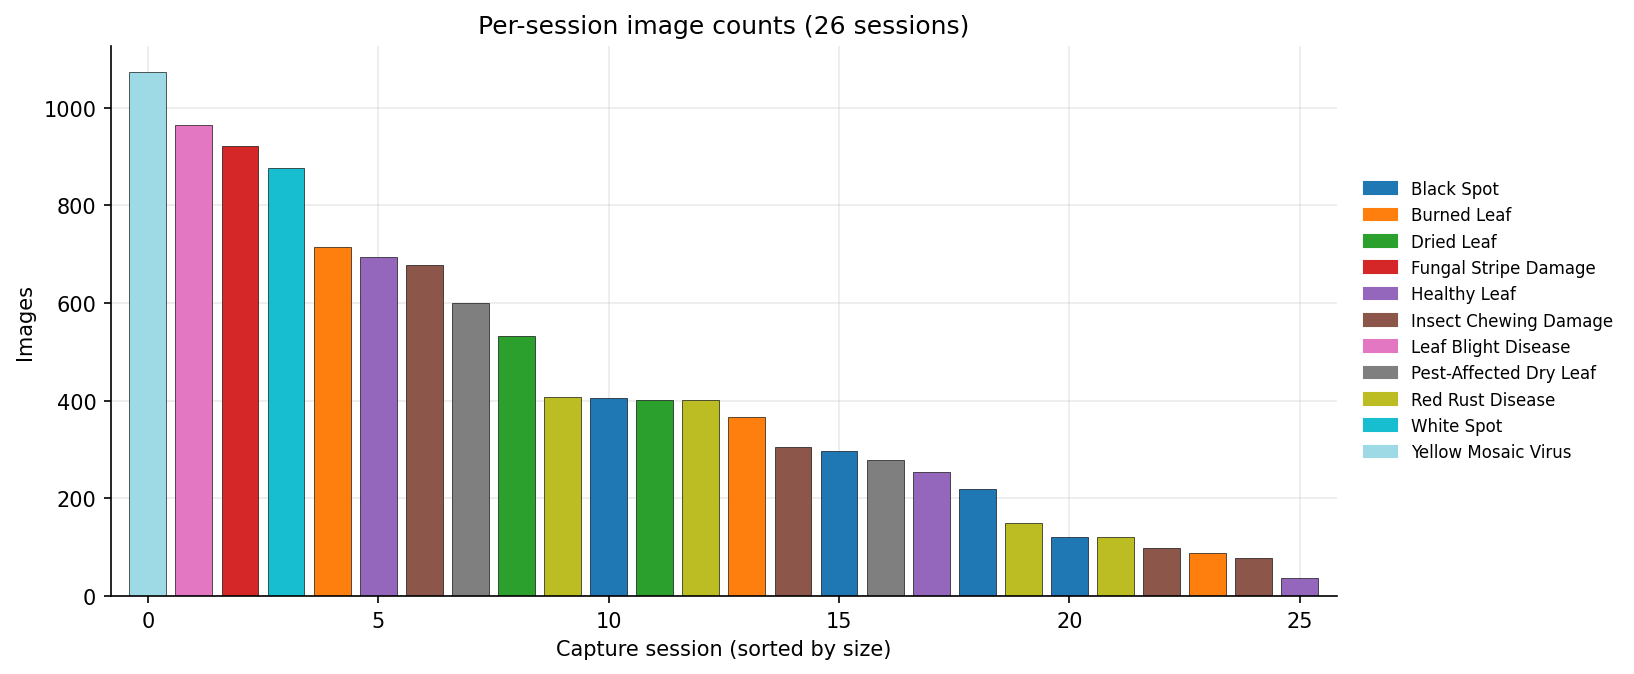

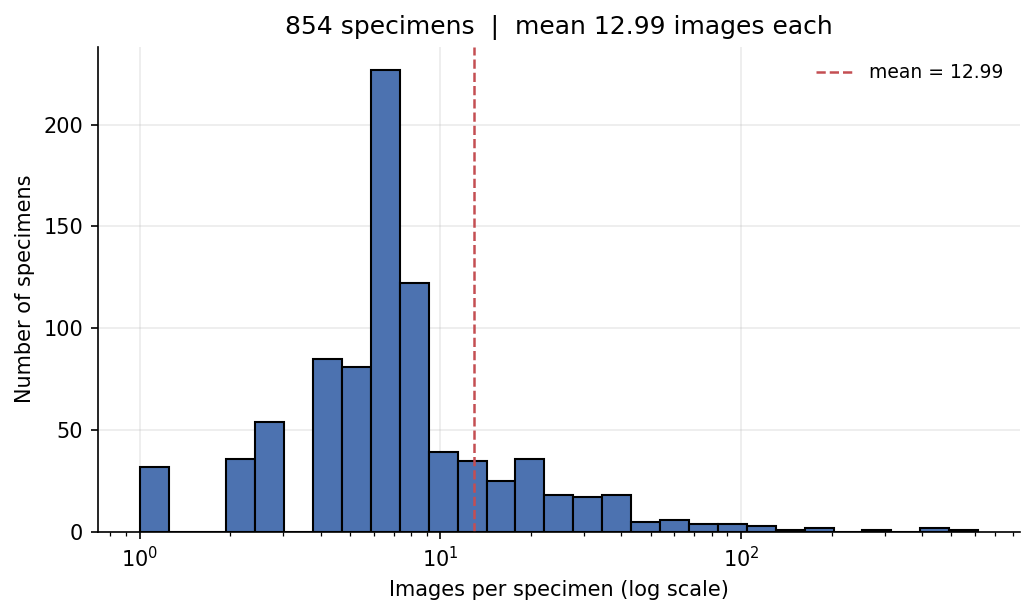

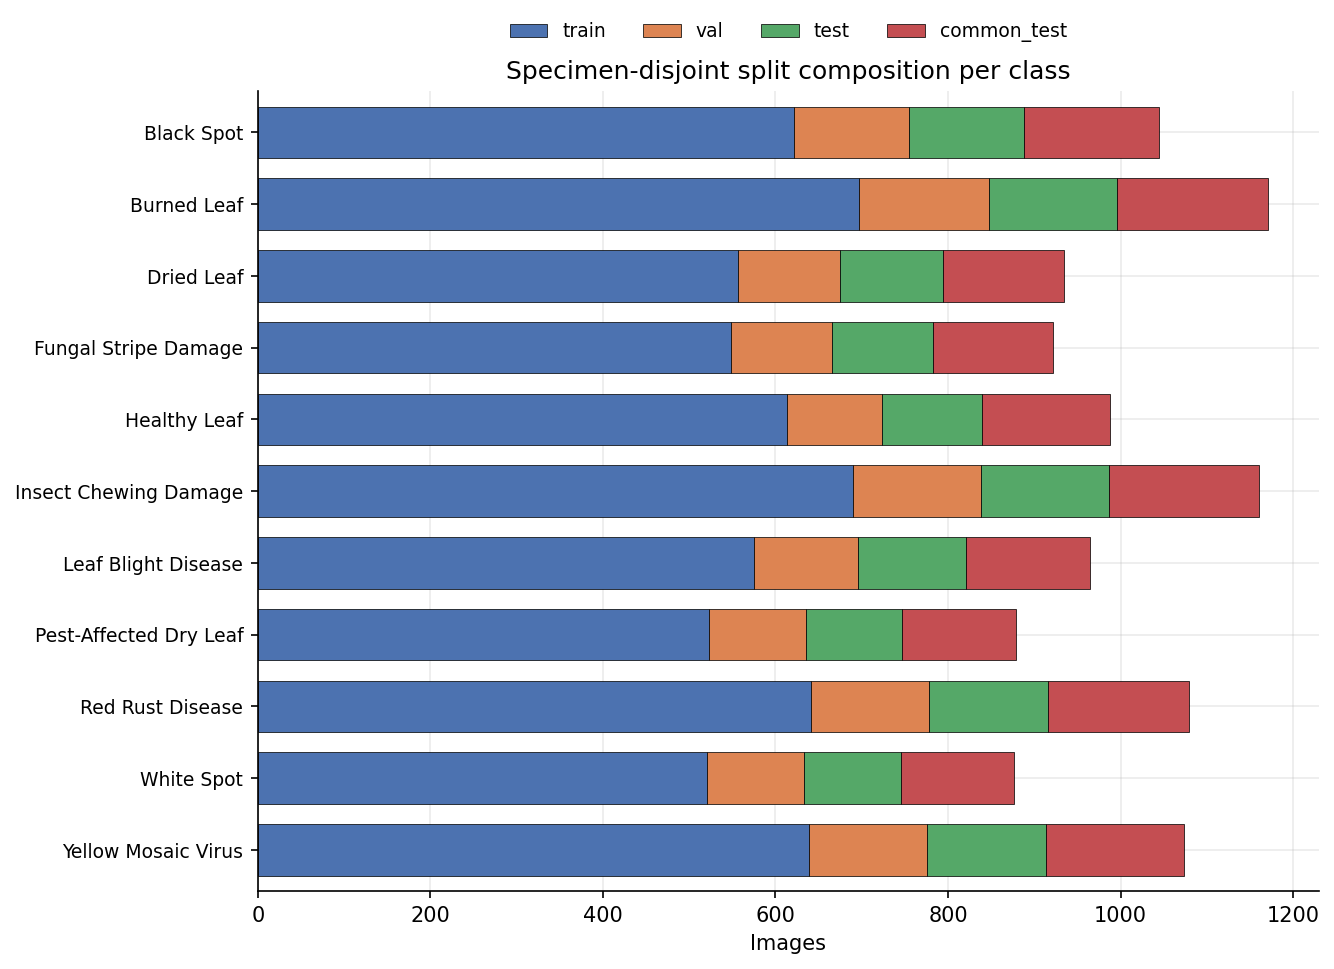

\begin{table}
\caption{BDLitchi composition after identity grouping. Classes with a single capture session cannot be separated at session level.}
\label{tab:dataset_composition}
\begin{tabular}{lrrrrr}
\toprule
Class & Images & Sessions & pHash cl. & Specimens & Img/spec. \\
\midrule
Black Spot & 1045 & 4 & 979 & 143 & 7.3 \\
Burned Leaf & 1171 & 3 & 437 & 82 & 14.3 \\
Dried Leaf & 934 & 2 & 875 & 87 & 10.7 \\
Fungal Stripe Damage & 922 & 1 & 141 & 51 & 18.1 \\
Healthy Leaf & 988 & 3 & 133 & 24 & 41.2 \\
Insect Chewing Damage & 1160 & 4 & 219 & 57 & 20.4 \\
Leaf Blight Disease & 965 & 1 & 177 & 21 & 46.0 \\
Pest-Affected Dry Leaf & 879 & 2 & 862 & 127 & 6.9 \\
Red Rust Disease & 1079 & 4 & 298 & 40 & 27.0 \\
White Spot & 877 & 1 & 776 & 62 & 14.2 \\
Yellow Mosaic Virus & 1074 & 1 & 1026 & 160 & 6.7 \\
\bottomrule
\end{tabular}
\end{table}



In [15]:
# ===== 9. Figures + LaTeX table =====
plt.rcParams.update({'figure.dpi':150,'savefig.dpi':300,'font.family':'DejaVu Sans',
 'font.size':10,'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,
 'grid.alpha':.25,'axes.axisbelow':True,'legend.frameon':False})
FIGD=OUT_DIR/'figures'; FIGD.mkdir(exist_ok=True)
labs=sorted(df.label.unique())
cmap=plt.cm.tab20(np.linspace(0,1,len(labs))); COL={l:cmap[i_] for i_,l in enumerate(labs)}

# --- Fig 1: per-session counts. Legend OUTSIDE the axes (was overlapping the bars) ---
sc=df.groupby(['label','session_id']).size().reset_index(name='n').sort_values('n',ascending=False)
fig,ax=plt.subplots(figsize=(11,4.6))
ax.bar(range(len(sc)),sc.n,color=[COL[l] for l in sc.label],edgecolor='k',lw=.3)
ax.set_xlabel('Capture session (sorted by size)'); ax.set_ylabel('Images')
ax.set_title(f'Per-session image counts ({df.session_id.nunique()} sessions)')
ax.set_xlim(-0.8,len(sc)-0.2)
h=[plt.Rectangle((0,0),1,1,color=COL[l]) for l in labs]
ax.legend(h,labs,fontsize=8,ncol=1,loc='center left',bbox_to_anchor=(1.01,0.5))
plt.tight_layout(); plt.savefig(FIGD/'fig_session_distribution.png',bbox_inches='tight'); plt.show()

# --- Fig 2: specimen sizes. Log-x histogram; readable at any grouping scale ---
sz=df.groupby('specimen_id').size().values
fig,ax=plt.subplots(figsize=(7,4.2))
if sz.max()>1:
    bins=np.logspace(0,np.log10(sz.max()+1),30)
    ax.hist(sz,bins=bins,color='#4C72B0',edgecolor='k',lw=.4); ax.set_xscale('log')
else:
    ax.hist(sz,bins=[0.5,1.5],color='#4C72B0',edgecolor='k',lw=.4)
ax.set_xlabel('Images per specimen (log scale)'); ax.set_ylabel('Number of specimens')
ax.set_title(f'{df.specimen_id.nunique():,} specimens  |  mean {sz.mean():.2f} images each')
ax.axvline(sz.mean(),color='#C44E52',ls='--',lw=1.2,label=f'mean = {sz.mean():.2f}')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIGD/'fig_specimen_sizes.png',bbox_inches='tight'); plt.show()

# --- Fig 3: split composition. Height scales with class count; no label overlap ---
comp=df.groupby(['label','group_split']).size().unstack(fill_value=0)
order=[c for c in ['train','val','test','common_test'] if c in comp.columns]
comp=comp[order].loc[labs]
fig,ax=plt.subplots(figsize=(9, max(4.0, 0.45*len(labs)+1.6)))
left=np.zeros(len(comp))
cols={'train':'#4C72B0','val':'#DD8452','test':'#55A868','common_test':'#C44E52'}
for c in order:
    ax.barh(range(len(comp)),comp[c].values,left=left,label=c,
            color=cols[c],edgecolor='k',lw=.35,height=0.72)
    left+=comp[c].values
ax.set_yticks(range(len(comp))); ax.set_yticklabels(comp.index,fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('Images'); ax.margins(y=0.02)
ax.set_title('Specimen-disjoint split composition per class')
ax.legend(fontsize=9,ncol=len(order),loc='lower center',bbox_to_anchor=(0.5,1.04))
plt.tight_layout(); plt.savefig(FIGD/'fig_split_composition.png',bbox_inches='tight'); plt.show()

# --- LaTeX table ---
tex=diag.rename(columns={'label':'Class','n_images':'Images','n_sessions':'Sessions',
   'n_clusters':'pHash cl.','n_specimens':'Specimens','imgs_per_specimen':'Img/spec.'})
tex=tex[['Class','Images','Sessions','pHash cl.','Specimens','Img/spec.']]
latex=tex.to_latex(index=False,escape=True,column_format='lrrrrr',
    float_format=lambda v:f'{v:.1f}',
    caption='BDLitchi composition after identity grouping. Classes with a single capture '
            'session cannot be separated at session level.',label='tab:dataset_composition')
open(OUT_DIR/'table_dataset_composition.tex','w').write(latex)
print(latex)